# Can you time the market by counting up days? 🧮📈
### The Japanese Psychological Line — a decades-old crowd-sentiment gauge, put through the desk's honest teardown

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-8b949e?style=flat-square)

The **Psychological Line** does one very simple thing: over the last 12 trading days, what fraction closed up? Above 75%, the story goes, "almost everyone who wanted to buy already has" — the crowd is exhausted, sell. Below 25%, the opposite — everyone's already sold, buy the capitulation.

It's an appealing idea: a pure vote-count of the crowd's recent mood, no price levels, no math beyond a fraction. We test it exactly as the charting books describe it — 12-day window, 75/25 thresholds — on SPY plus five liquid names, 23 years of daily data.

> 📓 **Plain-language layer.** Want the *t*-stats, the parameter grid and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every trade in this study enters the day *after* the signal, at that day's open — no trading on information you didn't have yet. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from psychological_line import data, strategy as st

HAVE_REAL = data.have_real()
BARS = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL,
      "| universe:", ", ".join(data.UNIVERSE) if HAVE_REAL else "n/a")

# frozen headline numbers (mirror of docs/results.md)
R = {'window': 12, 'oversold': 25, 'overbought': 75, 'hold': 5, 'start': '2003-01-02', 'end': '2026-06-30', 'n_low': 97, 'mean_low': 159.13, 'welch_low': 1.32, 'nw_low': 1.64, 'n_mid': 33074, 'mean_mid': 45.87, 'n_high': 398, 'mean_high': 66.09, 'welch_high': 1.04, 'nw_high': 1.1, 'per_ticker': {'SPY': (-0.2, 0.6), 'QQQ': (1.71, -1.28), 'IWM': (0.37, 0.57), 'AAPL': (0.63, 0.41), 'TSLA': (1.1, 1.21), 'NVDA': (-0.08, 0.68)}, 'timer_n': 495, 'timer5_strat_win': 41.0, 'timer5_strat_mean': -31.95, 'timer5_strat_t': -1.49, 'timer5_rand_win': 50.3, 'timer5_rand_mean': 18.57, 'timer5_rand_t': 0.69, 'timer10_strat_win': 39.6, 'timer10_strat_mean': -41.95, 'timer10_strat_t': -1.95, 'timer10_rand_win': 48.7, 'timer10_rand_mean': 8.57, 'timer10_rand_t': 0.32, 'delta_bps': -50.52, 'delta_t': -1.55, 'grid': [(10, 20, 80, 57, 1.29, 234, 1.15), (10, 25, 75, 354, 1.33, 949, 1.3), (10, 30, 70, 354, 1.33, 949, 1.3), (12, 20, 80, 97, 1.32, 398, 1.04), (12, 25, 75, 97, 1.32, 398, 1.04), (12, 30, 70, 454, 2.47, 1175, 0.87), (14, 20, 80, 19, 0.53, 162, 0.79), (14, 25, 75, 134, 0.8, 567, -0.35), (14, 30, 70, 534, 1.72, 1373, 0.49), (20, 20, 80, 0, None, 31, 0.55), (20, 25, 75, 13, 2.6, 158, 0.3), (20, 30, 70, 66, 2.17, 427, 0.98)], 'syn_null_lo_mean': -0.19, 'syn_null_lo_sd': 1.02, 'syn_null_lo_fire': 1, 'syn_null_hi_mean': -0.19, 'syn_null_hi_sd': 1.13, 'syn_null_hi_fire': 1, 'syn_planted_lo': 7.03, 'syn_planted_hi': -7.47, 'fp': {'SPY': 'c13d94f59e60', 'QQQ': '1bf28819a80b', 'IWM': '239b32ae95c3', 'AAPL': 'c3158a02623a', 'TSLA': '1d273fa4b475', 'NVDA': 'b6f76f845536'}}


real cache present: True | universe: SPY, QQQ, IWM, AAPL, TSLA, NVDA


## The answer first

| Question | Answer |
|---|---|
| Do stocks bounce after an oversold PSY reading? | **Maybe, but too faintly to trust.** After PSY drops below 25, the next 5 days average **+159 bps** vs +46 bps normally — the right direction, but with only 97 such events in 23 years, the signal is statistically indistinguishable from noise. |
| Do stocks fall after an overbought PSY reading? | **No — if anything, the opposite.** After PSY tops 75, the next 5 days average **+66 bps** — *more* positive than normal, not less. The "exhausted buyers" story doesn't show up in the data. |
| Can you trade it? | **Not profitably.** Buying oversold and shorting overbought, held 5 days, loses **-32 bps per trade** after realistic costs — worse the more you pay in fees. |
| Would a coin flip do better? | **On paper, yes.** A random buy-or-sell on the exact same days made **+19 bps** where the PSY rule lost 32 — though that gap itself isn't quite big enough to call statistically certain. |

> Counting up-days turns out to be a very blunt instrument.

## 1 · The claim

> *"When almost every recent day has closed up, the buyers who were going to buy have already bought — the next move is down. When almost every recent day has closed down, the sellers are spent — the next move is up."*

It's one of the older members of the Japanese technical-analysis toolkit — Steve Nison's *Beyond Candlesticks* carried it to English-speaking traders alongside candlestick patterns in the 1990s. Unlike most oscillators, PSY throws away *how much* each day moved and keeps only its sign — a pure vote count.

## 2 · So what?

If a simple up/down tally over 12 days genuinely predicted the next week's direction, that would be a remarkable finding — no price magnitude, no volume, no volatility adjustment, just a coin-flip tally beating a coin flip. It would also be trivially easy for anyone to compute and trade, which is exactly why, if real, it shouldn't still be sitting there unexploited 30+ years later.

## 3 · How would we even know?

- **The rule, exactly as written.** PSY(12) = 100 x (up-closes in the last 12 days) / 12. Below 25 = oversold/buy; above 75 = overbought/sell — the textbook thresholds, not tuned.
- **The comparison.** The 5-trading-day forward return after each signal vs. every other day, on SPY, QQQ, IWM, AAPL, TSLA and NVDA, 2003→2026.
- **The coin check.** The identical entry days and dates, but with the buy/sell decision made by a fair coin instead of PSY — the fairest test of whether the rule adds anything.
- **The luck check.** A synthetic world where we know the true answer, to prove the measuring stick itself isn't broken.

## 4 · The teardown — let's actually look

**First, the headline.** What happens in the 5 days *after* PSY hits an extreme?

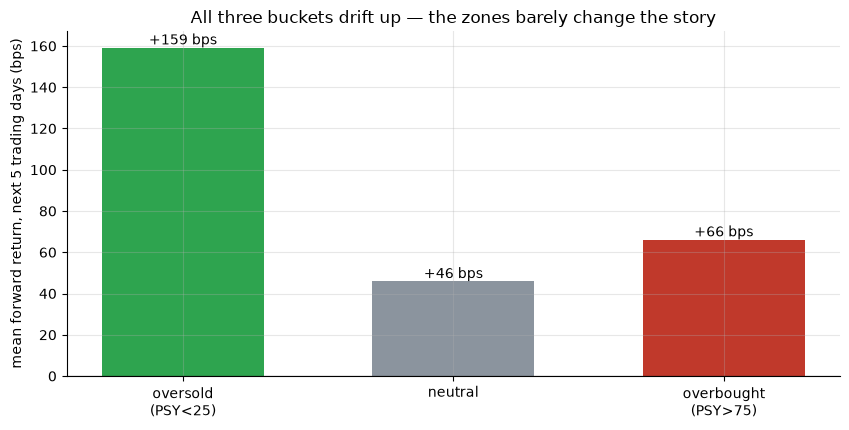

oversold +159.1  neutral +45.9  overbought +66.1 bps


In [2]:
if HAVE_REAL:
    c = st.pooled_conditional(BARS, window=R['window'], oversold=R['oversold'],
                             overbought=R['overbought'], h=R['hold'])
    lo, mid, hi = c['mean_low_bps'], c['mean_mid_bps'], c['mean_high_bps']
else:
    lo, mid, hi = R['mean_low'], R['mean_mid'], R['mean_high']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labels = ['oversold\n(PSY<25)', 'neutral', 'overbought\n(PSY>75)']
vals = [lo, mid, hi]
ax.bar(labels, vals, color=[GREEN, GREY, RED], width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return, next 5 trading days (bps)')
ax.set_title('All three buckets drift up — the zones barely change the story')
plt.tight_layout(); plt.show()
print(f'oversold {lo:+.1f}  neutral {mid:+.1f}  overbought {hi:+.1f} bps')

Oversold days *do* edge out the neutral bucket (**+159** vs **+46** bps) — but with only **97** such events in 23 years across six tickers, the statistics call it noise (Welch *t* = 1.32; the bar for "real" is 2). And overbought days? They average **+66** bps — *more* positive, not less. The market just tends to drift up in this window (23 years, mostly a bull market), and PSY extremes don't visibly change that drift either way.

**Now, the actual trade.** Would buying the oversold dips and shorting the overbought spikes have made money?

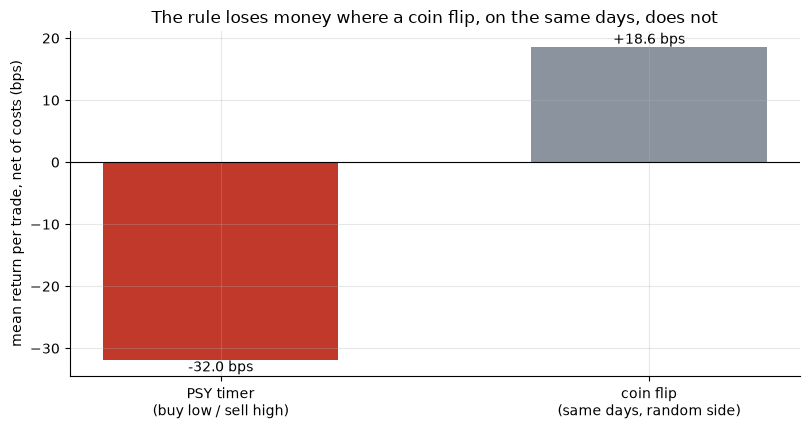

PSY timer -32.0 bps/trade  |  coin +18.6 bps/trade


In [3]:
if HAVE_REAL:
    strat, rand = st.pooled_trade_ledger(BARS, window=R['window'], oversold=R['oversold'],
                                         overbought=R['overbought'], hold_days=R['hold'],
                                         cost_bps=5.0, seed=679)
    ss, rs = st.summarize(strat, 'ret_net', lags=R['hold']), st.summarize(rand, 'ret_net', lags=R['hold'])
    sm, rm = ss['mean_bps'], rs['mean_bps']
else:
    sm, rm = R['timer5_strat_mean'], R['timer5_rand_mean']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['PSY timer\n(buy low / sell high)', 'coin flip\n(same days, random side)'],
       [sm, rm], color=[RED, GREY], width=.55)
for i, v in enumerate([sm, rm]): ax.annotate(f'{v:+.1f} bps', (i, v), ha='center',
    va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean return per trade, net of costs (bps)')
ax.set_title('The rule loses money where a coin flip, on the same days, does not')
plt.tight_layout(); plt.show()
print(f'PSY timer {sm:+.1f} bps/trade  |  coin {rm:+.1f} bps/trade')

The PSY rule loses **-32 bps per trade** (5 bps costs, 495 trades) — while a coin flip on the *exact same* entry days made **+19**. That's a **51 bps/trade** gap favoring the coin — real money on paper, though (the quants notebook shows) not quite big enough a sample to call it *certain* the coin truly beats the rule going forward. Either way, the rule itself is a net loser, and it gets worse the more you pay in trading costs.

## 5 · The verdict

- **Signal — None.** Neither the oversold nor the overbought leg reaches statistical significance, every individual stock/ETF checked out clean, and the overbought leg points the *wrong* way for the claim.
- **Tradability — Mirage.** Actually trading the zone crosses loses money net of costs, at every cost level tested.
- **"Beats a coin?" — Mixed.** The coin wins on paper by a wide margin, but the sample isn't quite large enough to certify that gap as more than luck.

## 6 · Going further 🚪

- **PSY throws away information on purpose** — no magnitude, no range, no volume. That's what makes it simple, and probably also what makes it weak: the desk's other oscillator studies, which *do* use magnitude or range, land in the same "None/Mirage" place anyway (see the dedup list below), so it's not obviously PSY's simplicity alone that's the problem — it may be that short-horizon "crowd exhaustion" just isn't a reliable phenomenon on liquid daily US equities.
- **Sibling studies:** [107-stochastic-oscillator](../../107-stochastic-oscillator/), [127-williams-r](../../127-williams-r/), [179-aroon](../../179-aroon/) and [680-disparity-index](../../680-disparity-index/) all test close relatives — none of them found a certifiable, tradable edge either.

*Think a longer window, an intraday version, or a volatility-scaled variant would fare better? The window x threshold grid in the quants notebook is the place to start — and the parameter-mining trap it walks through is worth reading first.*